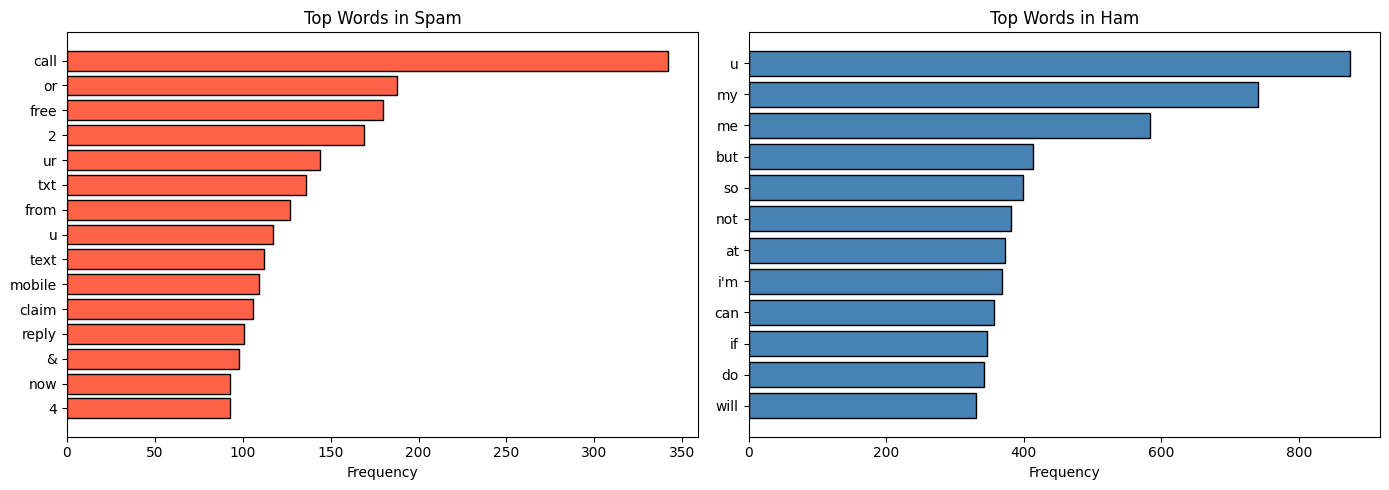

In [4]:
from collections import Counter

spam_text = " ".join(df[df['label'] == 1]['text'].str.lower())
ham_text  = " ".join(df[df['label'] == 0]['text'].str.lower())

stopwords = {'the','a','to','and','is','in','it','of','you','that','for',
             'on','are','with','this','have','i','your','we','be'}

spam_words = [(w, c) for w, c in Counter(spam_text.split()).most_common(30)
              if w not in stopwords][:15]
ham_words  = [(w, c) for w, c in Counter(ham_text.split()).most_common(30)
              if w not in stopwords][:15]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, words, color, title in zip(
        axes,
        [spam_words, ham_words],
        ['tomato', 'steelblue'],
        ['Top Words in Spam', 'Top Words in Ham']):
    labels, values = zip(*words)
    ax.barh(labels[::-1], values[::-1], color=color, edgecolor='black')
    ax.set_title(title)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../outputs/top_words.png', dpi=150)
plt.show()

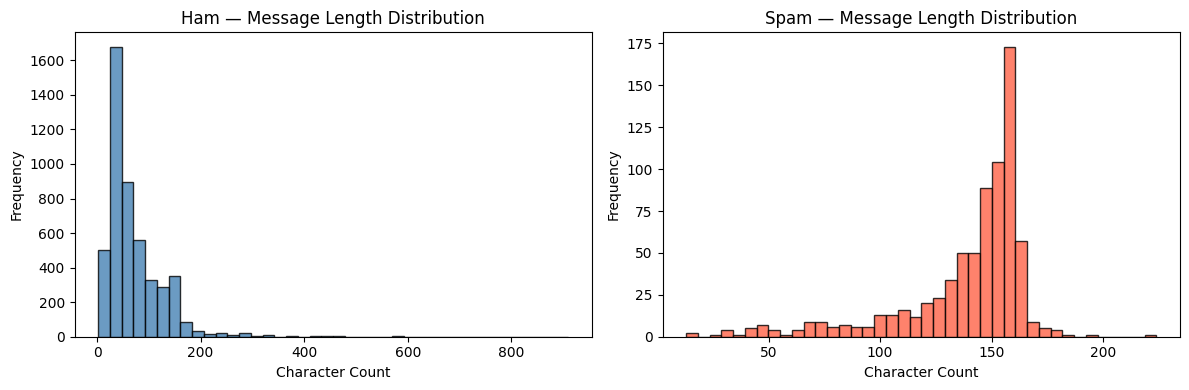

        count        mean        std   min    25%    50%    75%    max
label                                                                 
0      4825.0   71.023627  58.016023   2.0   33.0   52.0   92.0  910.0
1       747.0  138.866131  29.183082  13.0  132.5  149.0  157.0  224.0


In [3]:
df['length'] = df['text'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (label, name) in zip(axes, [(0, 'Ham'), (1, 'Spam')]):
    subset = df[df['label'] == label]['length']
    ax.hist(subset, bins=40, color='steelblue' if label == 0 else 'tomato',
            edgecolor='black', alpha=0.8)
    ax.set_title(f'{name} — Message Length Distribution')
    ax.set_xlabel('Character Count')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('../outputs/message_length_distribution.png', dpi=150)
plt.show()

print(df.groupby('label')['length'].describe())

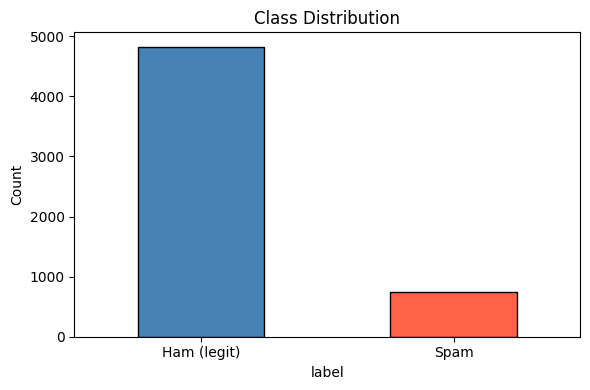

In [2]:
ax = df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'],
                                      edgecolor='black', figsize=(6, 4))
ax.set_xticklabels(['Ham (legit)', 'Spam'], rotation=0)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=150)
plt.show()

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.load_data import load_data

df = load_data('../data/spam.csv')
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
